In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append("..")
from sklearn.decomposition import NMF

from Src.data_modules import *

# Load data

In [ ]:
nb_sets = 4
nb_channels = 5

parrallel_multitaper_data = parallel_multitaper(nb_sets, nb_channels)

Calcul multitaper: 100%|██████████| 20/20 [00:59<00:00,  2.97s/it]


In [6]:
n,d = parrallel_multitaper_data[0].shape
flattened_multitaper_data = [arr.flatten() for arr in parrallel_multitaper_data] # Flatten les data
flattened_multitaper_data = [[x if x >= 0 else 0 for x in arr] for arr in flattened_multitaper_data] # Non-Negative values

# NMF construction

In [19]:
# Initialiser un modèle NMF
n_components = 3  # Nombre de composantes latentes
model = NMF(n_components=n_components, init='random', random_state=42)

# Ajuster le modèle sur les données
W = model.fit_transform(flattened_multitaper_data[:5])  # Matrice W (caractéristiques latentes)
H = model.components_ # Matrice H (poids des caractéristiques)

# NMF analysis

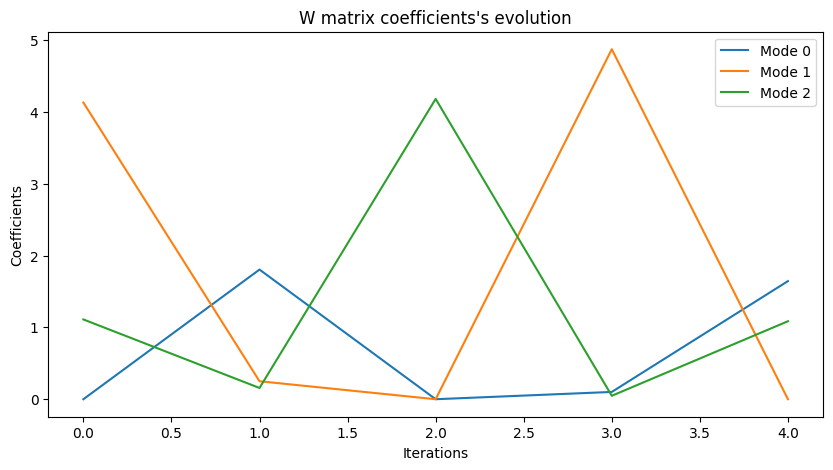

In [22]:
plt.figure(figsize=(10,5))

plt.plot(W)
plt.xlabel("Iterations")
plt.ylabel("Coefficients")
plt.title("W matrix coefficients's evolution")

plt.legend(["Mode {}".format(i) for i in range(n_components)])
plt.show()

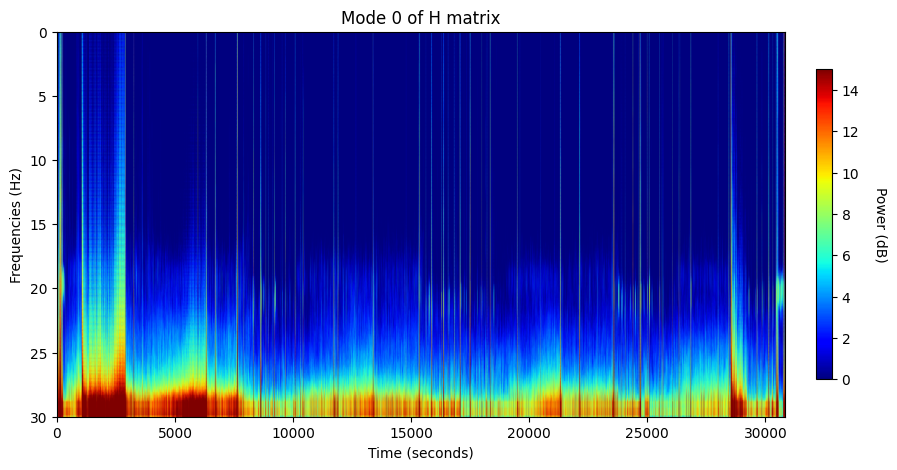

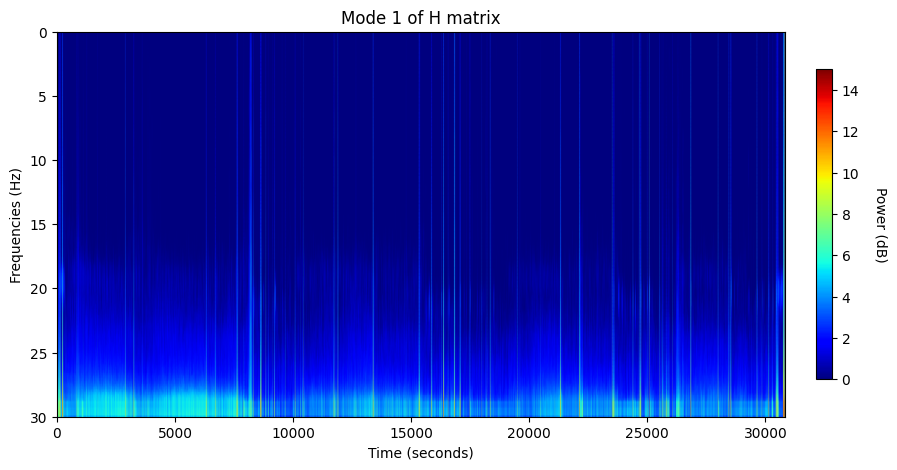

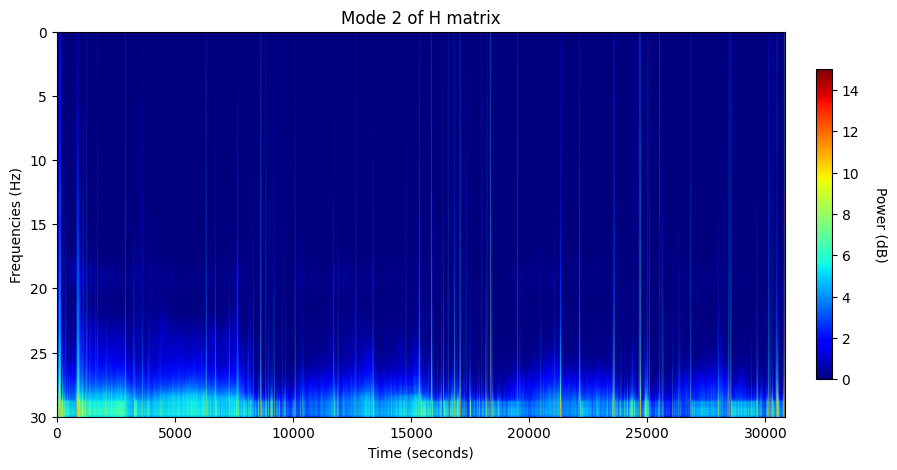

In [23]:
for i in range(n_components):
    fig, ax = plt.subplots(figsize=(10,5))

    cax = ax.imshow(np.reshape(H[i,:], (n,d)), aspect='auto', vmin=0, vmax=15, cmap="jet", extent=[0, d, 0, 30])

    cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label('Power (dB)', rotation=270, labelpad=20)

    ax.invert_yaxis()
    ax.set_title("Mode {} of H matrix".format(i))
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Frequencies (Hz)")

    plt.show()